 ## Importações

In [2]:
import pandas as pd
import numpy as np
import csv
import re
import matplotlib.pyplot as plt
from collections import Counter

import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB, GaussianNB
from sklearn.svm import LinearSVC
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)
from sklearn.metrics.pairwise import cosine_similarity

from gensim.models import Word2Vec

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, SimpleRNN
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

nltk.download('stopwords', quiet=True)

print("✅ Todas as bibliotecas importadas com sucesso!")

✅ Todas as bibliotecas importadas com sucesso!


 Carregamento dos Dados

In [3]:
params = {
    'sep': '\t',
    'names': ['text', 'label'],
    'header': None,
    'on_bad_lines': 'skip',
    'quoting': csv.QUOTE_NONE
}

train_df = pd.read_csv('data/train.tsv', **params)
test_df  = pd.read_csv('data/test.tsv',  **params)
dev_df   = pd.read_csv('data/dev.tsv',   **params)

print(f"Treino:    {len(train_df)} versos")
print(f"Validação: {len(dev_df)} versos")
print(f"Teste:     {len(test_df)} versos")
train_df.head()

Treino:    892 versos
Validação: 105 versos
Teste:     104 versos


,text,label
0,with pale blue berries. in these peaceful shad...,1
1,"it flows so long as falls the rain,",0
2,"and that is why, the lonesome day,",-1
3,"when i peruse the conquered fame of heroes, an...",2
4,of inward strife for truth and liberty.,2


 Distribuição das Classes

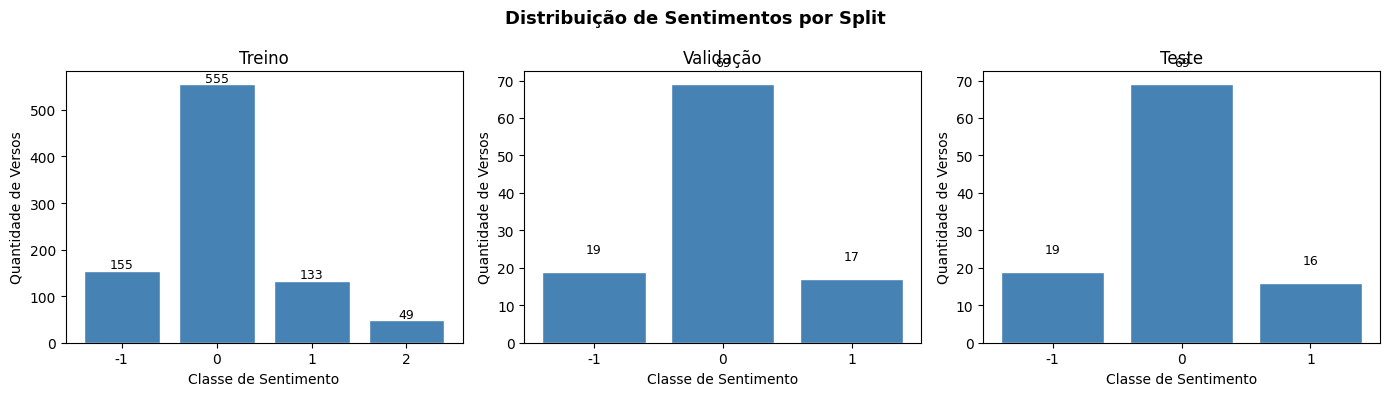

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle("Distribuição de Sentimentos por Split", fontsize=13, fontweight='bold')

for ax, (df, nome) in zip(axes, [(train_df, 'Treino'), (dev_df, 'Validação'), (test_df, 'Teste')]):
    contagem = df['label'].value_counts().sort_index()
    ax.bar(contagem.index.astype(str), contagem.values, color='steelblue', edgecolor='white')
    ax.set_title(nome)
    ax.set_xlabel("Classe de Sentimento")
    ax.set_ylabel("Quantidade de Versos")
    for i, v in enumerate(contagem.values):
        ax.text(i, v + 5, str(v), ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('distribuicao_classes.png', dpi=150, bbox_inches='tight')
plt.show()

Pré-processamento (Experimentos 1 e 2)

In [5]:
stop_words = set(stopwords.words('english'))
stemmer = PorterStemmer()

def limpar_texto(text, modo_avancado=False):
    # Experimento 1 — básico: lowercase + remove pontuação
    text = str(text).lower()
    text = re.sub(r'[^\w\s]', '', text)

    # Experimento 2 — avançado: remove stopwords + stemming
    if modo_avancado:
        tokens = text.split()
        text = " ".join([stemmer.stem(w) for w in tokens if w not in stop_words])
    return text

# Aplicar nos três splits
for df in [train_df, dev_df, test_df]:
    df['simples']  = df['text'].apply(lambda x: limpar_texto(x, modo_avancado=False))
    df['avancado'] = df['text'].apply(lambda x: limpar_texto(x, modo_avancado=True))

print("✅ Pré-processamento aplicado nos três splits.")
print("\nExemplo comparativo:")
train_df[['text', 'simples', 'avancado']].head()

✅ Pré-processamento aplicado nos três splits.

Exemplo comparativo:


,text,simples,avancado
0,with pale blue berries. in these peaceful shad...,with pale blue berries in these peaceful shades,pale blue berri peac shade
1,"it flows so long as falls the rain,",it flows so long as falls the rain,flow long fall rain
2,"and that is why, the lonesome day,",and that is why the lonesome day,lonesom day
3,"when i peruse the conquered fame of heroes, an...",when i peruse the conquered fame of heroes and...,perus conquer fame hero victori mighti gener e...
4,of inward strife for truth and liberty.,of inward strife for truth and liberty,inward strife truth liberti


Palavras Mais Frequentes por Sentimento

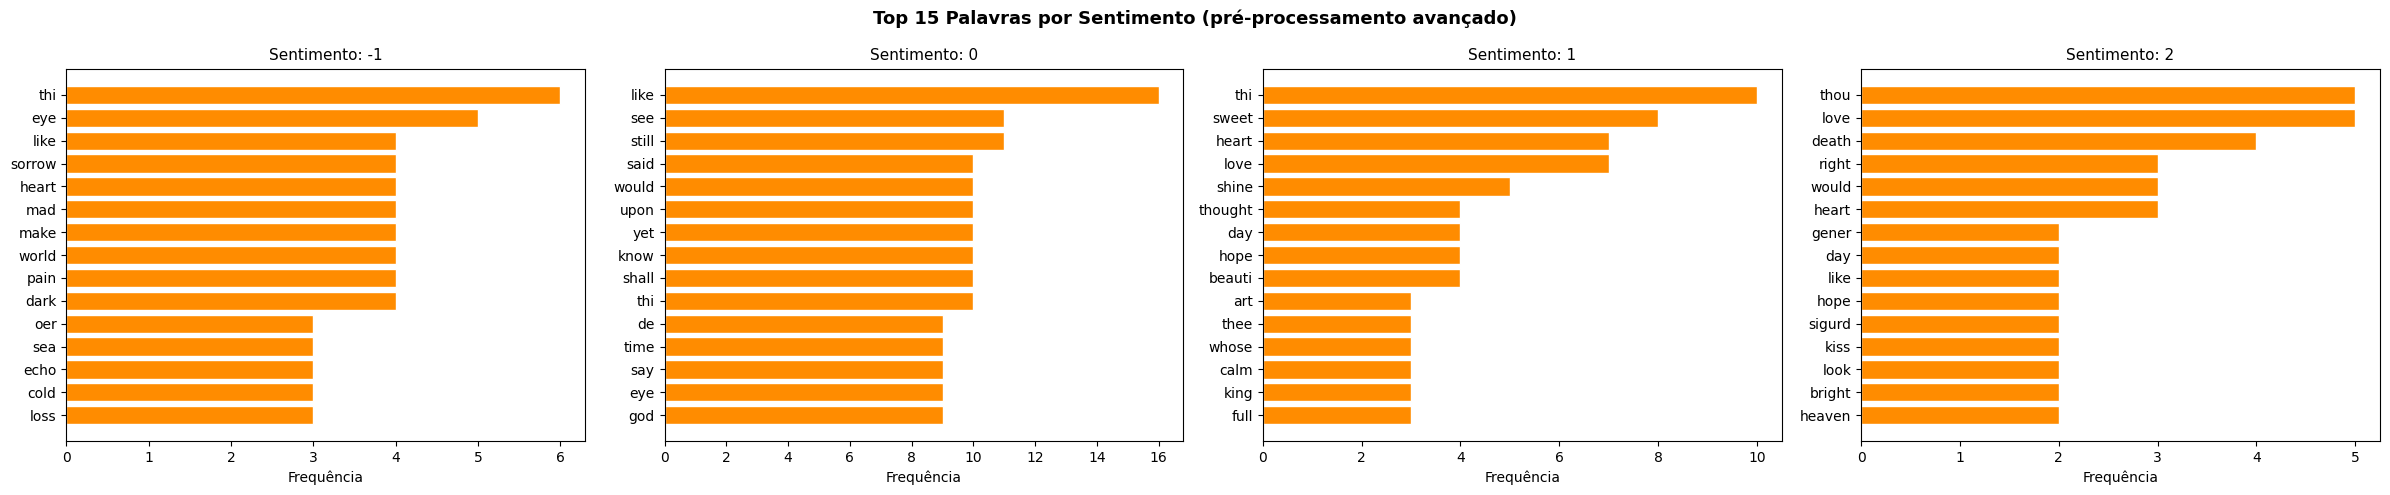

In [6]:
sentimentos = sorted(train_df['label'].unique())
fig, axes = plt.subplots(1, len(sentimentos), figsize=(6 * len(sentimentos), 5))
fig.suptitle("Top 15 Palavras por Sentimento (pré-processamento avançado)", fontsize=13, fontweight='bold')

if len(sentimentos) == 1:
    axes = [axes]

for ax, sentimento in zip(axes, sentimentos):
    versos = train_df[train_df['label'] == sentimento]['avancado']
    todas_palavras = " ".join(versos).split()
    mais_comuns = Counter(todas_palavras).most_common(15)
    palavras, frequencias = zip(*mais_comuns)

    ax.barh(palavras[::-1], frequencias[::-1], color='darkorange', edgecolor='white')
    ax.set_title(f"Sentimento: {sentimento}", fontsize=11)
    ax.set_xlabel("Frequência")

plt.tight_layout()
plt.savefig('palavras_por_sentimento.png', dpi=150, bbox_inches='tight')
plt.show()

Representação 1: TF-IDF

In [7]:
tfidf = TfidfVectorizer()
X_train_tfidf = tfidf.fit_transform(train_df['avancado'])

# Só transform no dev e test — nunca fit!
X_dev_tfidf  = tfidf.transform(dev_df['avancado'])
X_test_tfidf = tfidf.transform(test_df['avancado'])

print(f"✅ TF-IDF — vocabulário com {X_train_tfidf.shape[1]} palavras únicas.")
print(f"   Shape treino: {X_train_tfidf.shape}")
print(f"   Shape teste:  {X_test_tfidf.shape}")

✅ TF-IDF — vocabulário com 1890 palavras únicas.
   Shape treino: (892, 1890)
   Shape teste:  (104, 1890)


 Representação 2: Word2Vec

In [8]:
corpus_tokenizado = [verso.split() for verso in train_df['avancado']]

w2v_model = Word2Vec(
    sentences=corpus_tokenizado,
    vector_size=100,
    window=5,
    min_count=1,
    workers=4,
    seed=42
)

def verso_para_vetor(verso, model):
    tokens = verso.split()
    vetores = [model.wv[p] for p in tokens if p in model.wv]
    if len(vetores) == 0:
        return np.zeros(model.vector_size)
    return np.mean(vetores, axis=0)

X_train_w2v = np.array([verso_para_vetor(v, w2v_model) for v in train_df['avancado']])
X_dev_w2v   = np.array([verso_para_vetor(v, w2v_model) for v in dev_df['avancado']])
X_test_w2v  = np.array([verso_para_vetor(v, w2v_model) for v in test_df['avancado']])

print(f"✅ Word2Vec — Shape treino: {X_train_w2v.shape}")
print(f"             Shape teste:  {X_test_w2v.shape}")

✅ Word2Vec — Shape treino: (892, 100)
             Shape teste:  (104, 100)


Modelos Tradicionais: Naive Bayes e SVM

In [9]:
# ── Naive Bayes com TF-IDF ────────────────────────────────────────────────────
modelo_nb = MultinomialNB()
modelo_nb.fit(X_train_tfidf, train_df['label'])
y_pred_nb = modelo_nb.predict(X_test_tfidf)

# ── SVM com TF-IDF ────────────────────────────────────────────────────────────
modelo_svm = LinearSVC(max_iter=2000, random_state=42)
modelo_svm.fit(X_train_tfidf, train_df['label'])
y_pred_svm = modelo_svm.predict(X_test_tfidf)

# ── Naive Bayes com Word2Vec (Gaussian aceita valores negativos) ──────────────
modelo_gnb = GaussianNB()
modelo_gnb.fit(X_train_w2v, train_df['label'])
y_pred_gnb = modelo_gnb.predict(X_test_w2v)

# ── SVM com Word2Vec ──────────────────────────────────────────────────────────
modelo_svm_w2v = LinearSVC(max_iter=2000, random_state=42)
modelo_svm_w2v.fit(X_train_w2v, train_df['label'])
y_pred_svm_w2v = modelo_svm_w2v.predict(X_test_w2v)

# ── Tabela comparativa ────────────────────────────────────────────────────────
acc_nb      = accuracy_score(test_df['label'], y_pred_nb)
acc_svm     = accuracy_score(test_df['label'], y_pred_svm)
acc_gnb     = accuracy_score(test_df['label'], y_pred_gnb)
acc_svm_w2v = accuracy_score(test_df['label'], y_pred_svm_w2v)

print("╔══════════════════════════════════════════════════╗")
print("║     Comparação de Representações e Modelos       ║")
print("╠══════════════════════╦═══════════╦═══════════════╣")
print("║ Modelo               ║  TF-IDF   ║   Word2Vec    ║")
print("╠══════════════════════╬═══════════╬═══════════════╣")
print(f"║ Naive Bayes          ║  {acc_nb:.2%}   ║   {acc_gnb:.2%}      ║")
print(f"║ SVM                  ║  {acc_svm:.2%}   ║   {acc_svm_w2v:.2%}      ║")
print("╚══════════════════════╩═══════════╩═══════════════╝")

╔══════════════════════════════════════════════════╗
║     Comparação de Representações e Modelos       ║
╠══════════════════════╦═══════════╦═══════════════╣
║ Modelo               ║  TF-IDF   ║   Word2Vec    ║
╠══════════════════════╬═══════════╬═══════════════╣
║ Naive Bayes          ║  66.35%   ║   56.73%      ║
║ SVM                  ║  74.04%   ║   66.35%      ║
╚══════════════════════╩═══════════╩═══════════════╝


 Matrizes de Confusão

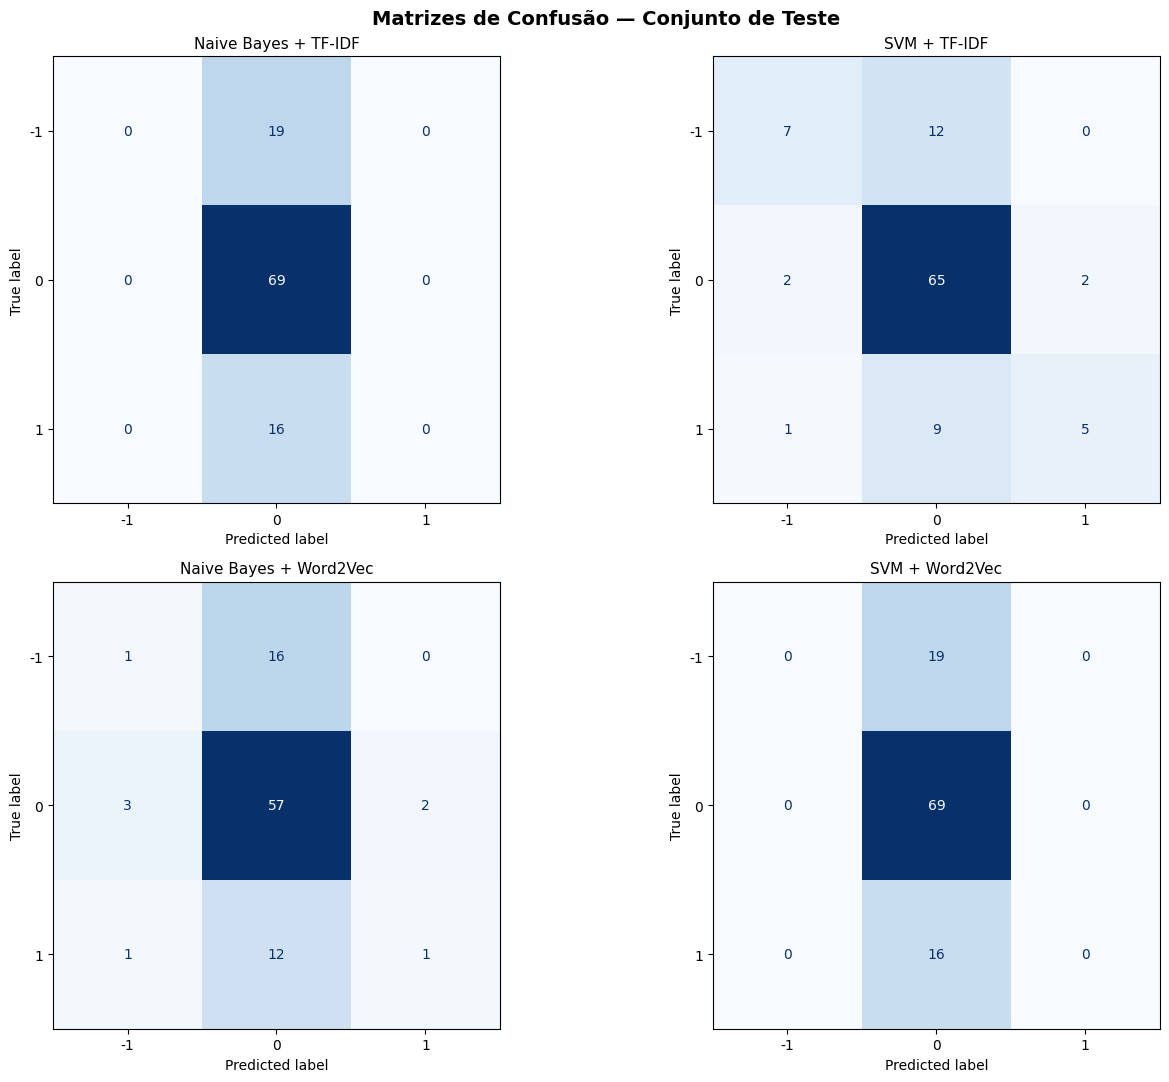

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(14, 11))
fig.suptitle("Matrizes de Confusão — Conjunto de Teste", fontsize=14, fontweight='bold')

nomes_classes = sorted(test_df['label'].unique())

combinacoes = [
    (y_pred_nb,      "Naive Bayes + TF-IDF"),
    (y_pred_svm,     "SVM + TF-IDF"),
    (y_pred_gnb,     "Naive Bayes + Word2Vec"),
    (y_pred_svm_w2v, "SVM + Word2Vec"),
]

for ax, (y_pred, titulo) in zip(axes.flatten(), combinacoes):
    cm = confusion_matrix(test_df['label'], y_pred, labels=nomes_classes)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=nomes_classes)
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(titulo, fontsize=11)

plt.tight_layout()
plt.savefig('matrizes_confusao.png', dpi=150, bbox_inches='tight')
plt.show()

 Relatórios de Classificação

In [11]:
print("── Naive Bayes + TF-IDF ──")
print(classification_report(test_df['label'], y_pred_nb))

print("── SVM + TF-IDF ──")
print(classification_report(test_df['label'], y_pred_svm))

print("── Naive Bayes + Word2Vec ──")
print(classification_report(test_df['label'], y_pred_gnb))

print("── SVM + Word2Vec ──")
print(classification_report(test_df['label'], y_pred_svm_w2v))

── Naive Bayes + TF-IDF ──
              precision    recall  f1-score   support

          -1       0.00      0.00      0.00        19
           0       0.66      1.00      0.80        69
           1       0.00      0.00      0.00        16

    accuracy                           0.66       104
   macro avg       0.22      0.33      0.27       104
weighted avg       0.44      0.66      0.53       104

── SVM + TF-IDF ──
              precision    recall  f1-score   support

          -1       0.70      0.37      0.48        19
           0       0.76      0.94      0.84        69
           1       0.71      0.31      0.43        16
           2       0.00      0.00      0.00         0

    accuracy                           0.74       104
   macro avg       0.54      0.41      0.44       104
weighted avg       0.74      0.74      0.71       104

── Naive Bayes + Word2Vec ──
              precision    recall  f1-score   support

          -1       0.20      0.05      0.08        19


c:\Users\J\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\J\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\J\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifi

Similaridade entre Versos

In [12]:
# Pegar o primeiro verso e encontrar o mais similar no corpus
similaridade = cosine_similarity(X_train_tfidf[0], X_train_tfidf)
indices_similares = similaridade.argsort()[0][::-1]  # do mais ao menos similar

print("── Análise de Similaridade (TF-IDF + Cosseno) ──\n")
print(f"Verso de referência: {train_df['text'].iloc[0]}")
print(f"Sentimento real:     {train_df['label'].iloc[0]}\n")

print("Versos mais similares:")
for rank, idx in enumerate(indices_similares[1:6], start=1):
    sim = similaridade[0][idx]
    print(f"  {rank}. [{sim:.2f}] {train_df['text'].iloc[idx]}  (sentimento: {train_df['label'].iloc[idx]})")

── Análise de Similaridade (TF-IDF + Cosseno) ──

Verso de referência: with pale blue berries. in these peaceful shades--
Sentimento real:     1

Versos mais similares:
  1. [0.34] on that shaded day,  (sentimento: 0)
  2. [0.22] and thus each tint or shade which falls,  (sentimento: 0)
  3. [0.20] lift their blue woods in broken chain  (sentimento: 0)
  4. [0.18] for peace or rest too well he saw  (sentimento: 0)
  5. [0.17] far out, in peace, the white man's sail  (sentimento: 0)


 Redes Neurais: RNN e LSTM

In [13]:
# ── Preparação das sequências ─────────────────────────────────────────────────
tokenizer_nn = Tokenizer()
tokenizer_nn.fit_on_texts(train_df['avancado'])
total_palavras = len(tokenizer_nn.word_index) + 1

input_sequences = []
for line in train_df['avancado']:
    token_list = tokenizer_nn.texts_to_sequences([line])[0]
    for i in range(1, len(token_list)):
        input_sequences.append(token_list[:i+1])

max_len = max([len(x) for x in input_sequences])
input_sequences = np.array(pad_sequences(input_sequences, maxlen=max_len, padding='pre'))
X_gen = input_sequences[:, :-1]
y_gen = tf.keras.utils.to_categorical(input_sequences[:, -1], num_classes=total_palavras)

print(f"✅ Sequências preparadas — total: {len(input_sequences)}, comprimento máximo: {max_len}")

# ── Definição dos modelos ─────────────────────────────────────────────────────
def criar_modelo(tipo='RNN'):
    model = Sequential([
        Embedding(total_palavras, 50, input_length=max_len - 1),
        SimpleRNN(100) if tipo == 'RNN' else LSTM(100),
        Dense(total_palavras, activation='softmax')
    ])
    model.compile(loss='categorical_crossentropy', optimizer='adam')
    return model

# ── Treinamento (guardando histórico para o gráfico) ─────────────────────────
print("\nTreinando RNN...")
rnn_model = criar_modelo('RNN')
hist_rnn = rnn_model.fit(X_gen, y_gen, epochs=15, verbose=0)
print("✅ RNN concluída.")

print("Treinando LSTM...")
lstm_model = criar_modelo('LSTM')
hist_lstm = lstm_model.fit(X_gen, y_gen, epochs=15, verbose=0)
print("✅ LSTM concluída.")

✅ Sequências preparadas — total: 2645, comprimento máximo: 11

Treinando RNN...


c:\Users\J\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\core\embedding.py:103: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


✅ RNN concluída.
Treinando LSTM...
✅ LSTM concluída.


Curvas de Treino RNN vs LSTM

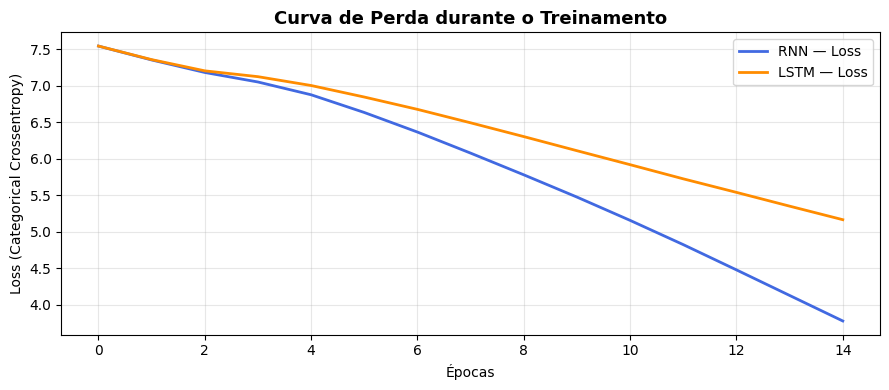

In [14]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(hist_rnn.history['loss'],  label='RNN — Loss',  color='royalblue',  linewidth=2)
ax.plot(hist_lstm.history['loss'], label='LSTM — Loss', color='darkorange', linewidth=2)
ax.set_title("Curva de Perda durante o Treinamento", fontsize=13, fontweight='bold')
ax.set_xlabel("Épocas")
ax.set_ylabel("Loss (Categorical Crossentropy)")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('curvas_treino_rnn_lstm.png', dpi=150, bbox_inches='tight')
plt.show()

Geração de Texto: RNN vs LSTM

In [15]:
def gerar_verso(modelo, texto_semente, proximas_palavras=6):
    for _ in range(proximas_palavras):
        tokens = tokenizer_nn.texts_to_sequences([texto_semente])[0]
        tokens = pad_sequences([tokens], maxlen=max_len - 1, padding='pre')
        previsao = np.argmax(modelo.predict(tokens, verbose=0), axis=-1)
        saida = ""
        for palavra, index in tokenizer_nn.word_index.items():
            if index == previsao:
                saida = palavra
                break
        texto_semente += " " + saida
    return texto_semente

sementes = ["love", "dark", "beauty", "death"]

print(f"{'Semente':<10} {'RNN':<40} {'LSTM'}")
print("=" * 90)
for semente in sementes:
    rnn_out  = gerar_verso(rnn_model,  semente)
    lstm_out = gerar_verso(lstm_model, semente)
    print(f"{semente:<10} {rnn_out:<40} {lstm_out}")

Semente    RNN                                      LSTM
love       love heart way anchor roun base lave     love like wild stream swarm crown gener
dark       dark look know rain eye man eye          dark like burn know know thi quit
beauty     beauty hath thi know name eye man        beauty mourn mid fame drew flame flame
death      death thi know name eye man could        death word fli root angel crown bretherin


Análise Crítica de Erros

In [16]:
test_df['pred_svm'] = y_pred_svm
erros = test_df[test_df['label'] != test_df['pred_svm']][['text', 'label', 'pred_svm']]

print(f"Total de erros do SVM (TF-IDF) no teste: {len(erros)} de {len(test_df)} versos\n")
print("── 10 Exemplos de Erros ──")
print(erros.head(10).to_string(index=False))

print("\n── Análise Detalhada de um Erro ──")
exemplo = erros.iloc[0]
print(f"Verso:    {exemplo['text']}")
print(f"Real:     {exemplo['label']}")
print(f"Previsto: {exemplo['pred_svm']}")

print("""
Por que o modelo errou?
─────────────────────────────────────────────────────────────────────
1. Ambiguidade intencional — o mesmo verso pode expressar ironia,
   metáfora ou tristeza com as mesmas palavras superficiais.
2. Escassez léxica — versos curtos geram poucos tokens, e o TF-IDF
   tem pouca informação para decidir.
3. Inversão sintática — a ordem das palavras na poesia é muitas vezes
   invertida para rima/métrica, confundindo modelos bag-of-words.
4. Sentimento implícito — o poema transmite emoção pelo ritmo e
   contexto, não apenas por palavras com valência clara.
─────────────────────────────────────────────────────────────────────
""")

Total de erros do SVM (TF-IDF) no teste: 27 de 104 versos

── 10 Exemplos de Erros ──
                                                                    text  label  pred_svm
                                        with which his house is haunted;     -1         0
        lo now, o daughter of kings, let us rise in the face of the day,      1         0
                                      as o'er the earth it wanders wide,      0        -1
                                   how hearts were answering to his own,      1        -1
glad on its stone-built hearth; and thorough the wide-mouthed smoke-flue      0         1
                                ’tis to behold his vengeance for my son.     -1         0
                                            i cannot tell rude listeners     -1         0
                         those wastes of frozen billows that were hurled     -1         0
                           may george, beloved by all the nations round,      1         0
              

Automático vs. Interpretação Humana

In [17]:
amostra = test_df.sample(5, random_state=7)[['text', 'label', 'pred_svm']]

print("Comparação: Classificação Automática vs. Rótulo Humano")
print("=" * 70)
for _, row in amostra.iterrows():
    acordo = "✅ Correto" if row['label'] == row['pred_svm'] else "❌ Divergente"
    print(f"Verso:   {row['text']}")
    print(f"Humano:  {row['label']}  |  Modelo: {row['pred_svm']}  |  {acordo}")
    print("-" * 70)

print("""
Reflexão:
─────────────────────────────────────────────────────────────────────
Anotadores humanos também discordam entre si em textos poéticos, o
que indica alto grau de subjetividade inerente ao gênero. Modelos
treinados com TF-IDF capturam frequência de palavras, mas ignoram:
  • Tom e voz lírica do poema
  • Contexto cultural e histórico
  • Ironia e ambiguidade semântica
  • Ritmo e estrutura métrica como portadores de sentimento

Textos objetivos (notícias, avaliações) têm sentimento explícito e
vocabulário previsível — daí a enorme diferença de desempenho entre
os dois domínios.
─────────────────────────────────────────────────────────────────────
""")

Comparação: Classificação Automática vs. Rótulo Humano
Verso:   glad on its stone-built hearth; and thorough the wide-mouthed smoke-flue
Humano:  0  |  Modelo: 1  |  ❌ Divergente
----------------------------------------------------------------------
Verso:   midway the floor (with thatch was it strewn) burned ever the fire-flame
Humano:  0  |  Modelo: 0  |  ✅ Correto
----------------------------------------------------------------------
Verso:   the fear of angels, awful though they be,
Humano:  -1  |  Modelo: -1  |  ✅ Correto
----------------------------------------------------------------------
Verso:   shall troy renew’d be forc’d and fir’d again?
Humano:  0  |  Modelo: 0  |  ✅ Correto
----------------------------------------------------------------------
Verso:   the life of love that gave it--settles.
Humano:  1  |  Modelo: 2  |  ❌ Divergente
----------------------------------------------------------------------

Reflexão:
──────────────────────────────────────────────────────────